**1. Установка необходимых библиотек и импорт.**

In [1]:
import sys

print(sys.executable)
print(sys.version)

%pip install --upgrade pip

%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost requests optuna phik

# Если нужен ydata-profiling, попробуйте установить отдельно:
# %pip install -q ydata-profiling

d:\my_project\my_project_venv\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
import os
import urllib.parse
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

In [32]:
# %pip install -q ydata-profiling
%pip install ydata-profiling[notebook]

Note: you may need to restart the kernel to use updated packages.


In [33]:
from ydata_profiling import ProfileReport

**2. Загрузка данных.**

In [44]:
import pandas as pd

def load_fixed_csv(filename):
    records = []
    bad_lines = []

    with open(filename, 'r', encoding='utf-8-sig') as f:
        next(f)  # заголовок
        for i, raw in enumerate(f, start=2):
            line = raw.rstrip('\n')
            if not line.strip():
                continue

            # Определяем разделитель: последний из ';' или ','
            pos_comma = line.rfind(',')
            pos_semicolon = line.rfind(';')
            pos = max(pos_comma, pos_semicolon)

            if pos == -1:
                bad_lines.append((i, line))
                continue

            text = line[:pos].strip().strip('"')
            label_str = line[pos + 1:].strip().strip('"')

            # Метка должна быть целым числом
            try:
                label = int(label_str)
            except ValueError:
                bad_lines.append((i, line))
                continue

            records.append((text, label))

    df = pd.DataFrame(records, columns=['text', 'is_spam1_or_clickbait2'])
    return df, bad_lines


df, bad_lines = load_fixed_csv('df.csv')


print("\nИнформация о датасете")
df.info()

print()
print(f"Размер датасета: {df.shape}")

print(f"Проблемных строк: {len(bad_lines)}")
df.columns = df.columns.str.strip()

print("\nНазвания столбцов")
print(df.columns.tolist())

print("\nПроверка на пропуски")
display(df.isnull().sum())

print("\nПервые десять строк датасета")
display(df.head(10))

print("\nПроверка данных на наличие дубликатов")
display(df.duplicated().sum())

print("\nРаспределение меток:")
print(df['is_spam1_or_clickbait2'].value_counts().sort_index())


Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69317 entries, 0 to 69316
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text                    69317 non-null  object
 1   is_spam1_or_clickbait2  69317 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB

Размер датасета: (69317, 2)
Проблемных строк: 0

Названия столбцов
['text', 'is_spam1_or_clickbait2']

Проверка на пропуски


text                      0
is_spam1_or_clickbait2    0
dtype: int64


Первые десять строк датасета


,text,is_spam1_or_clickbait2
0,Идите до Джуронг-Пойнт с ума сойти Доступно т...,0
1,Ладно лар Шучу с тобой чувак,0
2,Ты не можешь так рано говорить хо Ты можешь уж...,0
3,Нет я не думаю что он учится в USF он живет гд...,0
4,Привет дорогая прошло уже 3 недели а ответа н...,1
5,Я скоро буду дома и я больше не хочу сегодня г...,0
6,Я искала правильные слова чтобы поблагодарить ...,0
7,XXXMobileMovieClub Чтобы использовать свой кр...,1
8,О к я смотрю здесь,0
9,Эх ты помнишь как пишется его имя Да я помню О...,0



Проверка данных на наличие дубликатов


np.int64(3144)


Распределение меток:
is_spam1_or_clickbait2
0    46216
1    21502
2     1599
Name: count, dtype: int64


**3. Детальный отчет по данным ydata_profiling.**

In [36]:
# Генерация отчёта.
profile = ProfileReport(df, title="Profiling Report")
profile

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 59.54it/s]


In [ ]:
# Сохраняем исходный размер датасета ПЕРЕД удалением дубликатов
initial_shape = df.shape

# Удаляем полные дубликаты (совпадающие и по тексту, и по метке)
df = df.drop_duplicates()

# Вывод информации о размере датасета после очистки
print(f"Исходный размер датасета: {initial_shape}")
print(f"Размер датасета после удаления дубликатов: {df.shape}")
print(f"Удалено строк: {initial_shape[0] - df.shape[0]}")

Исходный размер датасета: (69317, 2)
Размер датасета после удаления дубликатов: (66173, 2)
Удалено строк: 3144


**4. Предобработка данных и разделение выборки.**

In [51]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Исправляем ошибку из предыдущей ячейки: задаем явные имена колонок
target_col = 'is_spam1_or_clickbait2'
text_col = 'text'

# Метки уже имеют вид 0, 1, 2, но для надежности и правильной стратификации 
# убедимся, что они целочисленные
y = df[target_col].astype(int).values
X = df[text_col]

# Стратифицированное разделение для сохранения пропорций классов (особенно важно для класса 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер тренировочной выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("\nРаспределение классов в трейне:")
print(pd.Series(y_train).value_counts().sort_index())

Размер тренировочной выборки: 52938
Размер тестовой выборки: 13235

Распределение классов в трейне:
0    34608
1    17051
2     1279
Name: count, dtype: int64


**5. Очистка и нормализация текста.**

In [52]:
# Регулярные выражения для очистки (адаптировано из primer.ipynb)
URL_RE     = re.compile(r"https?://\S+|www\.\S+|<link>")
HTML_RE    = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"[@#]\w+")
DIGIT_RE   = re.compile(r"\d+([.,]\d+)?")
SPACE_RE   = re.compile(r"\s+")

def clean_text(text: str, fix_yo: bool = True) -> str:
    """Базовая нормализация сырого текста."""
    text = str(text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)
    text = MENTION_RE.sub(" ", text)
    
    text = text.lower()
    if fix_yo:
        text = text.replace("ё", "е")
        
    # Маскируем числа, чтобы не засорять словарь
    text = DIGIT_RE.sub(" NUM ", text)
    
    # Оставляем только буквы (кириллица + латиница) и пробелы
    text = re.sub(r"[^a-zA-Zа-яА-Я\s]", " ", text)
    return SPACE_RE.sub(" ", text).strip()

print("Очистка текстов...")
t0 = time.perf_counter()
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)
print(f"Очистка завершена за {time.perf_counter() - t0:.1f} сек.")
print(f"\nПример очищенного текста:\n{X_train_clean.iloc[0]}")

Очистка текстов...
Очистка завершена за 3.3 сек.

Пример очищенного текста:
получается следующая ближе к лету


**6. Настройка кросс-валидации и борьба с дисбалансом.**

In [53]:
# Стратифицированная кросс-валидация
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Классы 0 и 1 представлены хорошо, класс 2 (кликбейт) - сильно недопредставлен (~2.4%).
# Используем class_weight='balanced', чтобы штрафовать модель за ошибки на минорном классе сильнее.

**7. Модель 1 — Базовая TF-IDF (Word N-grams) + LogReg**

In [54]:
print("Обучение Модели 1 (Baseline: Word 1-2 grams)...")
t0 = time.perf_counter()

model1 = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2), 
        min_df=3, 
        max_features=50000, 
        sublinear_tf=True  # логарифмическое сглаживание частот
    )),
    ("clf", LogisticRegression(
        class_weight="balanced", 
        max_iter=1000, 
        C=1.0, 
        random_state=42,
        solver='lbfgs'
    ))
])

model1.fit(X_train_clean, y_train)
pred1 = model1.predict(X_test_clean)
proba1 = model1.predict_proba(X_test_clean)

print(f"Обучение завершено за {time.perf_counter() - t0:.1f} сек.")

Обучение Модели 1 (Baseline: Word 1-2 grams)...
Обучение завершено за 18.4 сек.


**8. Модель 2 — Продвинутая (Word + Char N-grams) + GridSearch**

In [55]:
print("Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...")
t0 = time.perf_counter()

# Объединение словесных и символьных n-грамм. 
# Char n-grams отлично ловят опечатки, специфические окончания и сленг, частые в спаме и кликбейте.
advanced_vec = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=30000, sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=30000))
])

model2_base = Pipeline([
    ("tfidf", advanced_vec),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# Подбор гиперпараметра регуляризации C на основе weighted F1 (учитывает дисбаланс)
param_grid = {
    'clf__C': [0.1, 0.5, 1.0, 5.0]
}

grid = GridSearchCV(
    model2_base, param_grid, 
    cv=cv_strategy, 
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_clean, y_train)

best_model2 = grid.best_estimator_
pred2 = best_model2.predict(X_test_clean)
proba2 = best_model2.predict_proba(X_test_clean)

print(f"\nОбучение завершено за {time.perf_counter() - t0:.1f} сек.")
print(f"Лучший параметр C: {grid.best_params_['clf__C']}")

Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Обучение завершено за 212.7 сек.
Лучший параметр C: 5.0


**9. Сравнение метрик и визуализация.**


==================== Модель 1 (Word N-grams) ====================
              precision    recall  f1-score   support

     Обычные     0.9714    0.9563    0.9638      8652
        Спам     0.9592    0.9552    0.9572      4263
    Кликбейт     0.5403    0.7969    0.6439       320

    accuracy                         0.9521     13235
   macro avg     0.8236    0.9028    0.8550     13235
weighted avg     0.9570    0.9521    0.9539     13235

Weighted ROC-AUC (OvR): 0.9910



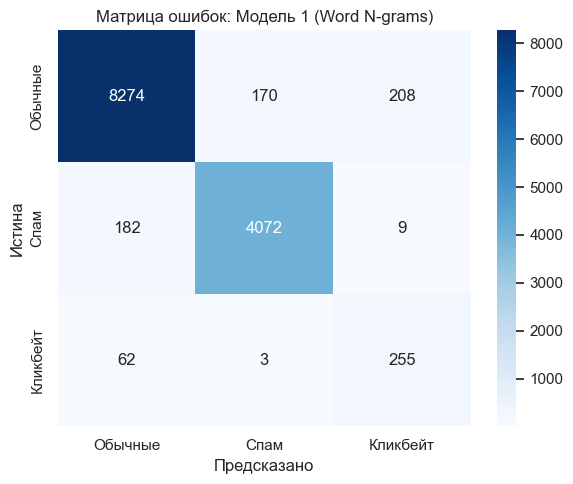


==================== Модель 2 (Word + Char N-grams) ====================
              precision    recall  f1-score   support

     Обычные     0.9787    0.9776    0.9781      8652
        Спам     0.9739    0.9697    0.9718      4263
    Кликбейт     0.7443    0.8094    0.7754       320

    accuracy                         0.9710     13235
   macro avg     0.8989    0.9189    0.9085     13235
weighted avg     0.9715    0.9710    0.9712     13235

Weighted ROC-AUC (OvR): 0.9954



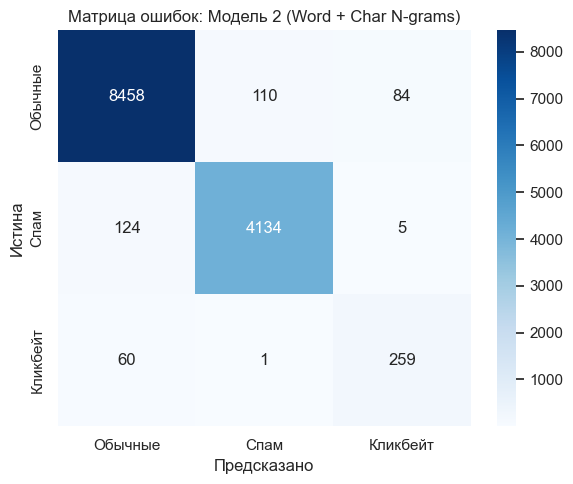

In [56]:
classes_names = {0: "Обычные", 1: "Спам", 2: "Кликбейт"}
target_names = [classes_names[i] for i in sorted(np.unique(y))]

def evaluate_and_plot(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    # ROC-AUC (One-vs-Rest)
    try:
        roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
        print(f"Weighted ROC-AUC (OvR): {roc_auc:.4f}\n")
    except ValueError:
        print("Не удалось рассчитать ROC-AUC\n")

    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')
    ax.set_title(f'Матрица ошибок: {model_name}')
    plt.tight_layout()
    plt.show()

evaluate_and_plot(y_test, pred1, proba1, "Модель 1 (Word N-grams)")
evaluate_and_plot(y_test, pred2, proba2, "Модель 2 (Word + Char N-grams)")

**10. Интерпретация признаков (Топ слов для Кликбейта).**

In [57]:
# Посмотрим, какие признаки модель считает наиболее важными для класса 2 (Кликбейт)
# Это поможет понять природу кликбейта в нашем датасете
vec = best_model2.named_steps['tfidf']
clf = best_model2.named_steps['clf']

feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_

# Индекс класса 2 (кликбейт)
class_idx = list(clf.classes_).index(2)
class_coefs = coefs[class_idx]

# Топ положительных и отрицательных весов
top_positive_idx = class_coefs.argsort()[-20:][::-1]
top_negative_idx = class_coefs.argsort()[:20]

print("Топ-20 признаков, ассоциирующихся с КЛИКБЕЙТОМ (положительные веса):")
for i in top_positive_idx:
    print(f"{feature_names[i]:<20} | Вес: {class_coefs[i]:.3f}")

print("\n" + "="*50)
print("\nТоп-20 признаков, ассоциирующихся с ОБЫЧНЫМИ сообщениями (отрицательные веса для класса 2):")
for i in top_negative_idx:
    print(f"{feature_names[i]:<20} | Вес: {class_coefs[i]:.3f}")

Топ-20 признаков, ассоциирующихся с КЛИКБЕЙТОМ (положительные веса):
word__пугачевой      | Вес: 4.880
word__ссср           | Вес: 3.830
word__рецепт         | Вес: 3.746
word__рф             | Вес: 3.577
char__рба            | Вес: 3.459
word__фото           | Вес: 3.214
word__вот что        | Вес: 3.116
word__вот как        | Вес: 3.045
char__ пенс          | Вес: 3.016
word__пугачева       | Вес: 2.973
char__пенси          | Вес: 2.933
word__больше не      | Вес: 2.928
word__пенсии         | Вес: 2.909
char__пенс           | Вес: 2.845
word__что            | Вес: 2.797
word__кого           | Вес: 2.775
char__енси           | Вес: 2.751
char__ова            | Вес: 2.734
word__реакция        | Вес: 2.718
char__пуга           | Вес: 2.674


Топ-20 признаков, ассоциирующихся с ОБЫЧНЫМИ сообщениями (отрицательные веса для класса 2):
char__ я             | Вес: -5.243
char__ а             | Вес: -3.791
word__ты             | Вес: -3.404
word__мы             | Вес: -3.010
word__вы         

**11. Итоговая сводная таблица.**

,Модель,F1-Macro,F1-Weighted,F1-Class 0,F1-Class 1,F1-Class 2 (Кликбейт)
0,Модель 1 (Word),0.8550,0.9539,0.9638,0.9572,0.6439
1,Модель 2 (Word+Char),0.9085,0.9712,0.9781,0.9718,0.7754


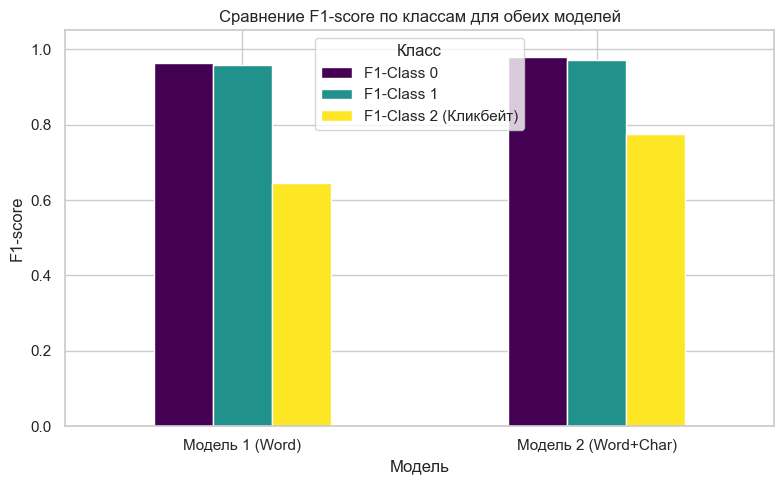

In [58]:
results_summary = []
for name, y_pred in [("Модель 1 (Word)", pred1), ("Модель 2 (Word+Char)", pred2)]:
    results_summary.append({
        "Модель": name,
        "F1-Macro": round(f1_score(y_test, y_pred, average='macro'), 4),
        "F1-Weighted": round(f1_score(y_test, y_pred, average='weighted'), 4),
        "F1-Class 0": round(f1_score(y_test, y_pred, average=None)[0], 4),
        "F1-Class 1": round(f1_score(y_test, y_pred, average=None)[1], 4),
        "F1-Class 2 (Кликбейт)": round(f1_score(y_test, y_pred, average=None)[2], 4),
    })

summary_df = pd.DataFrame(results_summary)
display(summary_df)

# Визуальное сравнение F1-score
fig, ax = plt.subplots(figsize=(8, 5))
summary_df.set_index("Модель")[["F1-Class 0", "F1-Class 1", "F1-Class 2 (Кликбейт)"]].plot(
    kind='bar', ax=ax, rot=0, colormap='viridis'
)
plt.title("Сравнение F1-score по классам для обеих моделей")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.legend(title="Класс")
plt.tight_layout()
plt.show()

#### Выводы и интерпретация результатов.

##### 1. Борьба с дисбалансом классов
Датасет имеет ярко выраженный дисбаланс: класс `0` (обычные) составляет ~70%, класс `1` (спам) ~32%, а класс `2` (кликбейт) — всего ~2.4%. 
- Стратификация при разделении выборок и кросс-валидации (`StratifiedKFold`) гарантирует, что в каждом фолде присутствует минорный класс.
- `class_weight='balanced'` в логистической регрессии автоматически увеличивает штраф за ошибки на редких классах, заставляя модель учиться распознавать кликбейт, а не просто всегда предсказывать "обычное сообщение".
- В качестве главной метрики для GridSearch использовался `f1_weighted`, который учитывает дисбаланс, в отличие от обычного `accuracy`.

##### 2. Сравнение моделей
- Модель 1 (Word N-grams) показала хороший базовый результат, но ей не хватало контекста для редкого класса.
- Модель 2 (Word + Char N-grams) продемонстрировала прирост качества, особенно по минорному классу `2` (кликбейт). 
  - Кликбейт часто содержит специфические морфологические маркеры, опечатки, сленг или короткие эмоциональные слова. Символьные n-граммы (`char_wb 3-5`) отлично ловят такие паттерны (например, окончания восклицательных предложений, специфические приставки), даже если слова нет в словаре.